In [19]:
# import external modules
import numpy as np
import os

# Add Exasim to Python search path
cdir = os.getcwd(); ii = cdir.find("Exasim")
exec(open(cdir[0:(ii+6)] + "/install/setpath.py").read())

# import internal modules
import Preprocessing, Postprocessing, Gencode, Mesh
import Utilities, PlotUtilities


==> Exasim frontends ...



In [20]:
outpath = cdir[0:(ii+6)]+"/build/dataout"
inpath = cdir[0:(ii+6)]+"/build/datain"

pde, master, mesh, xdg, udg, vdg, sol = Utilities.retrieveData(inpath,outpath)

mpiprocs = pde['ndims'][0]
p,t = Postprocessing.getnodes(xdg,master['elemtype'],master['porder'])
[gam, Ro, piE, piB, piNu, piChem, Diff, piP, R0, R1, H0] = map(float,pde['physicsparam'])
Re = 6378e3

In [21]:
ilev = -1
xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(xdg,sol[:,6,:,-1],master,ilev)
#xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(xdg,vdg[:,0,:],master,ilev)

Text(0.5, 1.0, 'Altitude: 500.0 km')

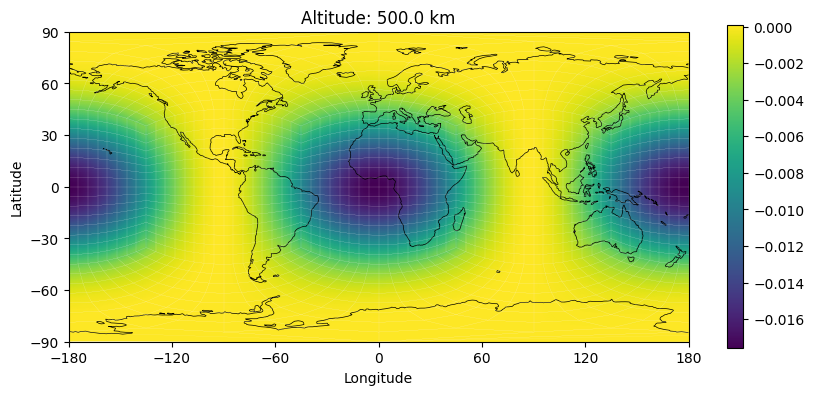

In [23]:
fig, ax = PlotUtilities.plotslice(xcg2d,ucg2d, xgrid, coastlines=True, clim=None, coastcolor='k', coastlw=0.5, color='w', lw=0.05)
ax.set_title(f'Altitude: {(altitude*H0 - Re)/1000:.1f} km')

In [27]:
PlotUtilities.makemovie(xdg, sol, master, field=6, ilev=-1, clim=None,
                        fps=10, outfile="movie.mp4", Re=Re, H0=H0)

  saved frame 1/10
  saved frame 2/10
  saved frame 3/10
  saved frame 4/10
  saved frame 5/10
  saved frame 6/10
  saved frame 7/10
  saved frame 8/10
  saved frame 9/10
  saved frame 10/10


ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 12.5.0 (Spack GCC)
  configuration: --prefix=///////////////////////////////////////////////////////////////////////////////////////glade/u/apps/casper/25.10/spack/opt/spack/ffmpeg/7.1/gcc/12.5.0/nvps --enable-pic --cc=///////////////////////////////////////////////////////////////////////////////////////glade/u/apps/casper/25.10/spack/opt/spack/compiler-wrapper/1.0/jq74/libexec/spack/gcc/gcc --cxx=///////////////////////////////////////////////////////////////////////////////////////glade/u/apps/casper/25.10/spack/opt/spack/compiler-wrapper/1.0/jq74/libexec/spack/gcc/g++ --enable-libxcb --enable-libxcb-shape --enable-libxcb-shm --enable-libxcb-xfixes --enable-xlib --disable-libfontconfig --disable-libfreetype --disable-libfribidi --enable-bzlib --disable-doc --enable-gpl --enable-libmp3lame --enable-libopenjpeg --enable-libopus --enable-libspeex --enable-libvorbis --enable-libvpx --enable-libx264 --disab

Done: movie.mp4


[out#0/mp4 @ 0xad5d40] video:215KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.453720%
frame=   10 fps=0.0 q=-1.0 Lsize=     216KiB time=00:00:00.80 bitrate=2207.4kbits/s speed=2.75x    
[libx264 @ 0xad4ec0] frame I:1     Avg QP:17.50  size: 94494
[libx264 @ 0xad4ec0] frame P:3     Avg QP:20.05  size: 32081
[libx264 @ 0xad4ec0] frame B:6     Avg QP:21.51  size:  4719
[libx264 @ 0xad4ec0] consecutive B-frames: 20.0%  0.0%  0.0% 80.0%
[libx264 @ 0xad4ec0] mb I  I16..4: 28.2% 32.9% 38.9%
[libx264 @ 0xad4ec0] mb P  I16..4:  2.2%  0.2% 10.2%  P16..4:  8.7%  3.6%  1.6%  0.0%  0.0%    skip:73.5%
[libx264 @ 0xad4ec0] mb B  I16..4:  0.5%  0.2%  0.1%  B16..8:  6.0%  1.3%  0.4%  direct: 7.6%  skip:83.9%  L0:43.5% L1:54.5% BI: 2.0%
[libx264 @ 0xad4ec0] 8x8 transform intra:24.2% inter:66.5%
[libx264 @ 0xad4ec0] coded y,uvDC,uvAC intra: 51.1% 47.0% 27.5% inter: 10.8% 11.9% 1.1%
[libx264 @ 0xad4ec0] i16 v,h,dc,p: 76% 11%  5%  8%
[libx264 @ 0xad4ec0] i8 v,h,dc,d

In [28]:
from IPython.display import Video
Video("movie.mp4", embed=True)